# Evaluering av RAG-chattbot
## Kostråd för gravida, spädbarn och småbarn

Denna notebook utvärderar chattbotens prestanda genom att:
1. Köra ett antal testfrågor genom RAG-systemet
2. Låta Gemini bedöma svaren på en skala 1–5
3. Sammanfatta resultaten i en tabell

**Betygsskala:**
- **5** = Utmärkt – korrekt, fullständigt och tydligt svar
- **4** = Bra – korrekt men kan vara mer fullständigt
- **3** = Godkänt – delvis korrekt eller otydligt
- **2** = Bristfälligt – felaktigt eller missar viktig information
- **1** = Underkänt – fel svar eller inget svar alls

In [54]:
import os
import time
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google import genai
from google.genai import types
from pypdf import PdfReader
from dotenv import load_dotenv

load_dotenv()
client = genai.Client(api_key=os.getenv("GENAI_API_KEY"), vertexai=False)
print("✅ Uppkopplad till Gemini API")

✅ Uppkopplad till Gemini API


## Steg 1 – Ladda in RAG-systemet

In [55]:
# Samma klasser och funktioner som i livsmedelsverket_kostrad_chattbot.py
class EmbeddingsSvar:
    def __init__(self, embeddings):
        self.embeddings = embeddings

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

def semantic_search(query, chunks, embeddings, top_k=3):
    query_response = client.models.embed_content(
        model="models/gemini-embedding-2-preview",
        contents=query,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY")
    )
    query_embedding = query_response.embeddings[0].values
    similarity_scores = []
    for i, chunk_embedding in enumerate(embeddings.embeddings):
        score = cosine_similarity(query_embedding, chunk_embedding.values)
        similarity_scores.append((i, score))
    similarity_scores.sort(key=lambda x: x[1], reverse=True)
    top_indices = [index for index, _ in similarity_scores[:top_k]]
    return [chunks[index] for index in top_indices]

def get_answer(question, chunks, embeddings):
    relevant_chunks = semantic_search(question, chunks, embeddings, top_k=3)
    context = "\n".join(relevant_chunks)
    prompt = f"""
    Du är en hjälpsam assistent för gravida, närstående till gravida, föräldrar med spädbarn eller småbarn.
    Använd endast information från PDF-filerna för att svara på frågan och ingen annan information.
    Om svaret inte finns i PDF-filerna, säg att du inte vet.
    Formulera dig enkelt och dela upp svaret i fina stycken - citera aldrig direkt från texten.
    Återge aldrig exakta meningar eller stycken från källmaterialet. Omformulera alltid informationen helt i egna ord.
    Ge alltid ett tydligt och enhetligt svar. Börja med en direkt rekommendation och förklara sedan varför.
    Om du får en fråga om barn utan specifik ålder, fråga efter specifik ålder innan du svarar.
    Undvik att säga något som motsäger dig själv i samma svar.
    Kom ihåg information från tidigare i konversationen, till exempel barnets ålder eller tidigare frågor och svar.
    Användaren har valt språk: Svenska. Svara alltid på svenska.
    Om användaren skriver något kort som "ok", "tack" eller liknande, svara kort och vänligt och påminn dem gärna om att de kan ställa fler frågor

    Information från PDF:
    {context}

    Fråga: {question}
    """
    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt
        )
        return response.text
    except Exception as e:
        return f"FEL: {e}"

print("✅ Funktioner laddade")

✅ Funktioner laddade


In [56]:
# Ladda PDF-filer och embeddings
filer = [
    "bra-mat-for-spadbarn-under-ett-ar-livsmedelsverket.pdf",
    "spaedbarn_kostrad.pdf",
    "1177_barnmat.pdf",
    "bra-mat-nar-du-ar-gravid-lattlast.pdf",
    "gravida_mat.pdf",
    "gravida_naring.pdf",
    "gravida_matmangd.pdf",
    "gravida_vego.pdf",
    "barn_vegetarisk.pdf",
    "barn_vegansk.pdf",
    "barn_1_2_ar.pdf"
]

text = ""
for fil in filer:
    reader = PdfReader(fil)
    for page in reader.pages:
        text += page.extract_text()

# Styckebaserad chunking – samma som i livsmedelsverket_kostrad_chattbot.py
def skapa_chunks(text, max_storlek=2000, overlap=200):
    stycken = [s.strip() for s in text.split("\n\n") if s.strip()]
    chunks = []
    nuvarande_chunk = ""
    for stycke in stycken:
        if len(nuvarande_chunk) + len(stycke) < max_storlek:
            nuvarande_chunk += stycke + "\n\n"
        else:
            if nuvarande_chunk:
                chunks.append(nuvarande_chunk.strip())
            nuvarande_chunk = nuvarande_chunk[-overlap:] + stycke + "\n\n"
    if nuvarande_chunk:
        chunks.append(nuvarande_chunk.strip())
    return chunks

chunks = skapa_chunks(text, max_storlek=2000, overlap=200)

print(f"✅ {len(chunks)} chunks skapade från {len(filer)} PDF-filer")

# Ladda embeddings från fil om den finns
if os.path.exists("embeddings.pkl"):
    with open("embeddings.pkl", "rb") as f:
        embeddings = pickle.load(f)
    print("✅ Embeddings laddade från embeddings.pkl")
else:
    print("⚠️ embeddings.pkl hittades inte – kör livsmedelsverket_kostrad_chattbot.py först för att skapa filen")

✅ 1 chunks skapade från 11 PDF-filer
✅ Embeddings laddade från embeddings.pkl


## Steg 2 – Testfrågor

5 testfrågor som täcker olika ämnen i chattboten:
- Honung till spädbarn
- Koffein under graviditet
- D-droppar till barn
- Risdryck till småbarn
- Folsyra under graviditet

In [57]:
testfrågor = [
    {"fråga": "Kan jag ge honung till min bebis på 8 månader?", "förväntat": "Nej, honung ska inte ges till barn under ett år eftersom det kan innehålla farliga bakterier som producerar giftet botulin."},
    {"fråga": "Hur mycket kaffe får jag dricka under graviditeten?", "förväntat": "Max 200 mg koffein per dag, vilket motsvarar ungefär 2-3 koppar bryggkaffe."},
    {"fråga": "Behöver mitt barn D-droppar?", "förväntat": "Ja, alla barn behöver D-droppar dagligen under de första två åren."},
    {"fråga": "Kan barn under 2 år äta risdryck?", "förväntat": "Nej, risdrycker innehåller arsenik och bör inte ges till barn under sex år."},
    {"fråga": "Ska jag ta folsyra när jag är gravid?", "förväntat": "Ja, 400 mikrogram folsyra per dag rekommenderas, helst från innan befruktning till vecka 12."},
]

print(f"✅ {len(testfrågor)} testfrågor redo")

✅ 5 testfrågor redo


## Steg 3 – Kör testfrågorna genom chattboten

In [58]:
print("Kör testfrågor... (detta kan ta några minuter)\n")

resultat = []
for i, test in enumerate(testfrågor):
    print(f"Fråga {i+1}/{len(testfrågor)}: {test['fråga'][:50]}...")
    svar = get_answer(test["fråga"], chunks, embeddings)
    resultat.append({
        "fråga": test["fråga"],
        "förväntat": test["förväntat"],
        "svar": svar
    })
    time.sleep(3)  # Undvik rate limiting

print("\n✅ Alla svar hämtade!")

Kör testfrågor... (detta kan ta några minuter)

Fråga 1/5: Kan jag ge honung till min bebis på 8 månader?...
Fråga 2/5: Hur mycket kaffe får jag dricka under graviditeten...
Fråga 3/5: Behöver mitt barn D-droppar?...
Fråga 4/5: Kan barn under 2 år äta risdryck?...
Fråga 5/5: Ska jag ta folsyra när jag är gravid?...

✅ Alla svar hämtade!


## Steg 4 – Låt Gemini bedöma svaren (LLM-as-a-judge)

In [59]:
def bedöm_svar(fråga, förväntat, svar):
    prompt = f"""
    Du är en expert på barnhälsa och kostråd. Din uppgift är att bedöma kvaliteten på ett svar från en chattbot.

    Fråga: {fråga}
    Förväntat svar (facit): {förväntat}
    Chattbotens svar: {svar}

    Bedöm svaret på en skala 1–5:
    5 = Utmärkt – korrekt, fullständigt och tydligt
    4 = Bra – korrekt men kan vara mer fullständigt
    3 = Godkänt – delvis korrekt eller otydligt
    2 = Bristfälligt – felaktigt eller missar viktig information
    1 = Underkänt – fel svar eller inget svar

    Svara ENDAST i detta format:
    BETYG: [siffra 1-5]
    MOTIVERING: [en mening]
    """
    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt
        )
        text = response.text.strip()
        betyg_rad = [r for r in text.split("\n") if r.startswith("BETYG:")]
        motivering_rad = [r for r in text.split("\n") if r.startswith("MOTIVERING:")]
        betyg = int(betyg_rad[0].replace("BETYG:", "").strip()) if betyg_rad else 0
        motivering = motivering_rad[0].replace("MOTIVERING:", "").strip() if motivering_rad else "Kunde inte bedöma"
        return betyg, motivering
    except Exception as e:
        return 0, f"Fel vid bedömning: {e}"

print("Bedömer svar... (detta kan ta några minuter)\n")

for i, r in enumerate(resultat):
    print(f"Bedömer svar {i+1}/{len(resultat)}...")
    betyg, motivering = bedöm_svar(r["fråga"], r["förväntat"], r["svar"])
    r["betyg"] = betyg
    r["motivering"] = motivering
    time.sleep(10)

print("\n✅ Alla svar bedömda!")

Bedömer svar... (detta kan ta några minuter)

Bedömer svar 1/5...
Bedömer svar 2/5...
Bedömer svar 3/5...
Bedömer svar 4/5...
Bedömer svar 5/5...

✅ Alla svar bedömda!


## Steg 5 – Visa resultat

In [60]:
# Skapa dataframe
df = pd.DataFrame(resultat)

# Visa sammanfattningstabell
sammanfattning = df[["fråga", "betyg", "motivering"]].copy()
sammanfattning.columns = ["Fråga", "Betyg (1-5)", "Motivering"]

pd.set_option("display.max_colwidth", 80)
print("=" * 80)
print("EVALUERINGSRESULTAT")
print("=" * 80)
print(sammanfattning.to_string(index=False))
print("=" * 80)
print(f"\nGenomsnittligt betyg: {df['betyg'].mean():.2f} / 5")
print(f"Högsta betyg: {df['betyg'].max()}")
print(f"Lägsta betyg: {df['betyg'].min()}")

EVALUERINGSRESULTAT
                                              Fråga  Betyg (1-5)                                                                                                                                                        Motivering
     Kan jag ge honung till min bebis på 8 månader?            5                                                   Svaret är korrekt, fullständigt och tydligt, och ger en utmärkt förklaring av riskerna med honung för spädbarn.
Hur mycket kaffe får jag dricka under graviditeten?            5                                Svaret är korrekt, fullständigt och mycket tydligt, och inkluderar även viktig kontextuell information som förbättrar förståelsen.
                       Behöver mitt barn D-droppar?            5                                     Svaret är korrekt, fullständigt och tydligt, och ger värdefull ytterligare information som överträffar det förväntade svaret.
                  Kan barn under 2 år äta risdryck?            5        

## Steg 6 – Visualisera resultaten

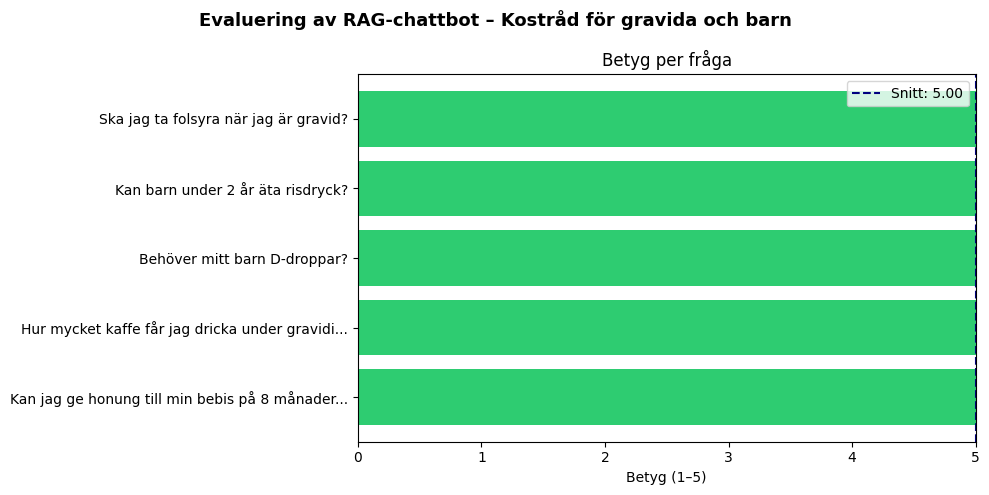

✅ Diagram sparat som evaluering_resultat.png


In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Evaluering av RAG-chattbot – Kostråd för gravida och barn", fontsize=13, fontweight="bold")

# Diagram – betyg per fråga
färger = ["#2ecc71" if b >= 4 else "#f39c12" if b == 3 else "#e74c3c" for b in df["betyg"]]
kortfrågor = [f[:45] + "..." if len(f) > 45 else f for f in df["fråga"]]
ax.barh(kortfrågor, df["betyg"], color=färger)
ax.set_xlim(0, 5)
ax.set_xlabel("Betyg (1–5)")
ax.set_title("Betyg per fråga")
ax.axvline(x=df["betyg"].mean(), color="navy", linestyle="--", label=f"Snitt: {df['betyg'].mean():.2f}")
ax.legend()

plt.tight_layout()
plt.savefig("evaluering_resultat.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Diagram sparat som evaluering_resultat.png")

## Steg 7 – Visa detaljerade svar

In [62]:
# Visa alla svar i detalj
for i, r in enumerate(resultat):
    print(f"\n{'='*70}")
    print(f"FRÅGA {i+1} – Betyg: {r['betyg']}/5")
    print(f"{'='*70}")
    print(f"❓ Fråga:      {r['fråga']}")
    print(f"✅ Förväntat:  {r['förväntat']}")
    print(f"🤖 Chattboten: {r['svar'][:300]}..." if len(r['svar']) > 300 else f"🤖 Chattboten: {r['svar']}")
    print(f"📝 Motivering: {r['motivering']}")


FRÅGA 1 – Betyg: 5/5
❓ Fråga:      Kan jag ge honung till min bebis på 8 månader?
✅ Förväntat:  Nej, honung ska inte ges till barn under ett år eftersom det kan innehålla farliga bakterier som producerar giftet botulin.
🤖 Chattboten: Nej, du ska inte ge honung till din bebis som är 8 månader.

Anledningen är att honung kan innehålla bakteriesporer. Dessa sporer kan i sällsynta fall utvecklas till bakterier i barnets tarmar och producera ett farligt gift. Därför bör honung inte ges till barn under ett år.
📝 Motivering: Svaret är korrekt, fullständigt och tydligt, och ger en utmärkt förklaring av riskerna med honung för spädbarn.

FRÅGA 2 – Betyg: 5/5
❓ Fråga:      Hur mycket kaffe får jag dricka under graviditeten?
✅ Förväntat:  Max 200 mg koffein per dag, vilket motsvarar ungefär 2-3 koppar bryggkaffe.
🤖 Chattboten: Som gravid bör du vara försiktig med hur mycket koffein du får i dig. För mycket koffein, särskilt tidigt i graviditeten, kan öka risken för missfall.

Du rekommenderas at

## Sammanfattning och slutsats

**Genomsnittligt betyg:** 5.00 / 5

**Styrkor:**
- Chattboten svarade korrekt och fullständigt på samtliga fem testfrågor och fick högsta möjliga betyg på alla
- Svaren var välstrukturerade och tydliga – botten gav inte bara rätt svar utan förklarade även varför, vilket är värdefullt för användaren
- Botten presterade bra på frågor som spänner över olika ämnesområden: säkerhet för spädbarn (honung), graviditet (kaffe och folsyra), allmänna barnhälsoråd (D-droppar) och kostråd (risdryck)

**Svagheter:**
- Evalueringen baserades på enbart 5 frågor, vilket gör det svårt att dra generella slutsatser om chattbotens prestanda över hela kunskapsbasen
- Serverinstabilitet hos Gemini-API:et försvårade evalueringsprocessen och ledde till att fler och mer heltäckande tester inte kunde genomföras

**Slutsats:**
Chattboten presterar utmärkt på de testade frågorna med ett genomsnittligt betyg på 5.00 av 5. RAG-systemet lyckas hämta och formulera korrekt information från källmaterialet och svaren är tydliga och pedagogiska. Det är dock viktigt att notera att evalueringen är begränsad i sin omfattning – med fler testfrågor skulle en mer nyanserad bild av chattbotens styrkor och svagheter framträda. För framtida förbättringar rekommenderas en mer omfattande evaluering när serverkapaciteten hos Gemini tillåter det.